<a href="https://colab.research.google.com/github/aishruban5566-ctrl/mlt-programs/blob/main/task_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

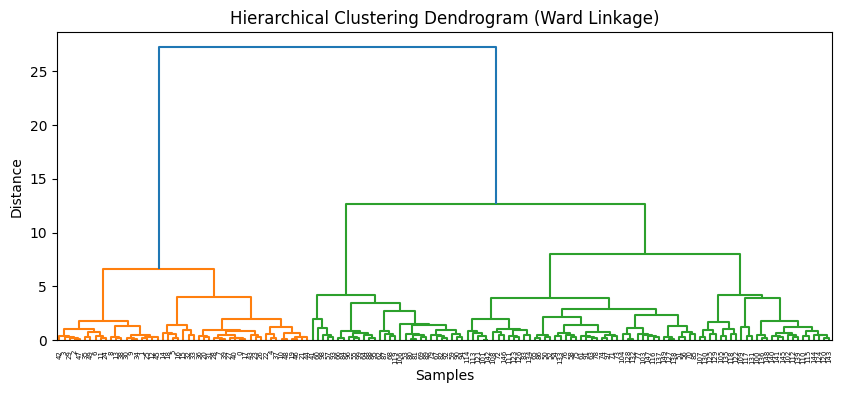

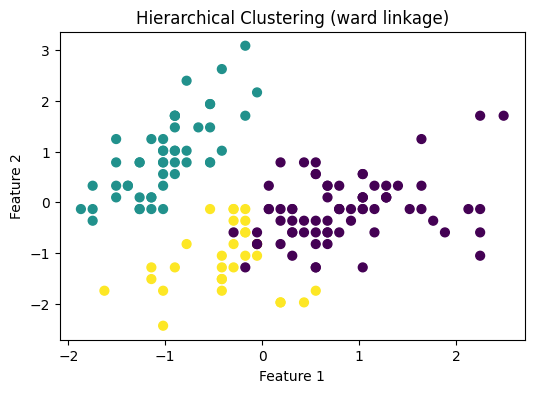

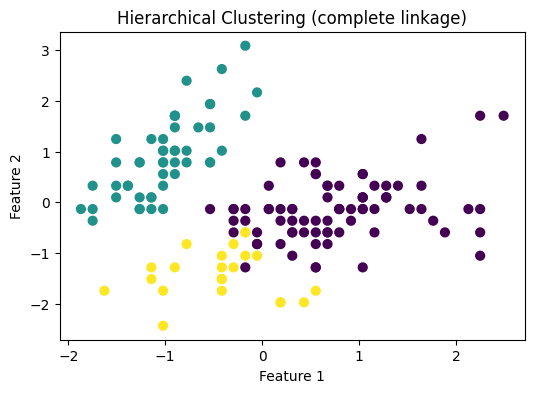

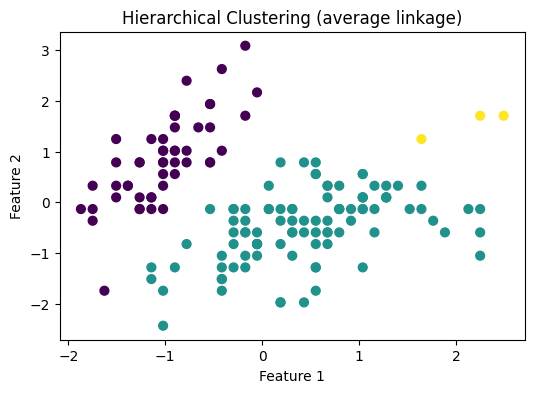

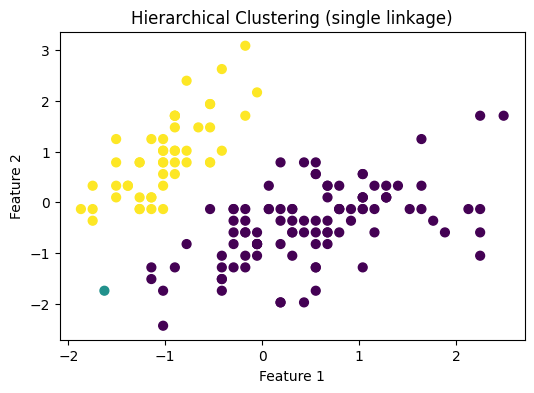


Clustering Quality Metrics:

  Linkage Method  Silhouette Score  Davies-Bouldin Index
0           ward          0.446689              0.803467
1       complete          0.449618              0.758358
2        average          0.480267              0.575269
3         single          0.504646              0.492925


In [ ]:
   import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import scipy.cluster.hierarchy as sch

# -----------------------
# 1. Load Dataset
# -----------------------
iris = load_iris()
X = iris.data
y = iris.target  # Ground truth for reference

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------
# 2. Dendrogram (to choose number of clusters)
# -----------------------
plt.figure(figsize=(10, 4))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# -----------------------
# 3. Apply Hierarchical Clustering
# -----------------------
# Trying different linkage criteria for comparison
linkage_methods = ["ward", "complete", "average", "single"]
results = []

for method in linkage_methods:
    clustering = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = clustering.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, labels)
    db_index = davies_bouldin_score(X_scaled, labels)
    results.append([method, sil_score, db_index])

    # Plotting the clustering result
    plt.figure(figsize=(6, 4))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=40)
    plt.title(f"Hierarchical Clustering ({method} linkage)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# -----------------------
# 4. Display Results
# -----------------------
results_df = pd.DataFrame(results, columns=["Linkage Method", "Silhouette Score", "Davies-Bouldin Index"])
print("\nClustering Quality Metrics:\n")
print(results_df)